In [1]:
import os, json, time, re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from openai import OpenAI
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
OPENROUTER_API_KEY = os.environ.get("OPENROUTER_API_KEY")
if OPENROUTER_API_KEY is None:
    raise ValueError("OPENROUTER_API_KEY is not set")

In [3]:
client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY
)

In [4]:
df = pd.read_csv(r"F:\Thesis\project\403-vekalat\structured_questions.csv")
df.head(3)

,question_number,category,question,options
0,1,حقوق مدنی,کدام یک از موارد زیر صحیح است؟,1) با توافق طرفین امکان از بین بردن سبب انفساخ...
1,2,حقوق مدنی,شخص «الف» حین رانندگی با خودرو سواری با شخص «ب...,1) دیه هر دو راننده صرفاً تا میزان دیه کامل و ...
2,3,حقوق مدنی,کدام مورد در خصوص تصرفی که همراه با قصد تملک ب...,1) تصرف در مواردی مملک است حتی اگر همراه با قص...


In [5]:
def to_list(opts):
    if isinstance(opts, list): return opts
    if isinstance(opts, str):
        try:
            v = json.loads(opts)
            if isinstance(v, list): return v
        except Exception: pass
        for sep in ["|","؛",";","/","\\","،","\n"]:
            if sep in opts: return [x.strip() for x in opts.split(sep) if x.strip()]
        return [opts.strip()]
    return [str(opts)]

In [6]:
def render_numeric_options(opts):
    return "\n".join(f"{i+1}) {o}" for i, o in enumerate(opts))

In [7]:
def build_messages(question: str, options_text: str):
    return [
        {
            "role": "system",
            "content": (
                "# Iranian Legal Question Answering System\n"
                "You are an expert in Iranian law.\n"
                "---\n"
                "## Instructions:\n"
                "- Language: Persian (فارسی)\n"
                "- Task: Based on Iranian law, choose the correct option number.\n"
                "- Provide ONLY the final choice and its confidence score.\n"
                "---\n"
                "## Confidence Scale (5 Levels):\n"
                "\n"
                "- 1: UNCERTAIN - Cannot distinguish between 2+ options\n"
                "\n"
                "- 2: WEAK - Significant doubt / Debatable interpretation\n"
                "\n"
                "- 3: MODERATE - Fairly confident / Standard interpretation\n"
                "\n"
                "- 4: STRONG - Confident / Clear code or precedent applies\n"
                "\n"
                "- 5: VERY STRONG - Certain / Unambiguous legal interpretation\n"
                "\n"
                "⚠️ Most questions: 2-4\n"
                "\n"
                "Output: {\"answer\":\"X\",\"confidence\":Y} where Y ∈ {1,2,3,4,5}\n"
                
                "## Output format:\n"
                "Return a single valid JSON object:\n"
                '{{"answer":"X","confidence":YY}}\n'
                "- answer: one of \"1\",\"2\",\"3\",\"4\" (select the correct option number)\n"
                "- confidence: one of {1, 2, 3, 4, 5}\n"
                "  * Based on how certain you are about this answer being correct under Iranian law\n"
                "---\n"
                "Output only raw JSON without any extra text or formatting."
            )
        },
        {
            "role": "user",
            "content": f"""سؤال:
{question}

گزینه‌ها:
{options_text}

Required output format:
{{"answer":"شماره_گزینه","confidence":میزان_اطمینان}}"""
        }
    ]


In [8]:
def extract_json(content: str, verbose: bool = False):
    """
    Extract the first valid JSON object from LLM response.
    Optimized for simple answer/confidence format.
    """
    import json, re

    if not content or not content.strip():
        if verbose:
            print("⚠️ Content is empty or None")
        return None

    content = content.strip()

    # Remove markdown code fences (```...```)
    if content.startswith("```"):
        lines = content.split("\n")
        # Remove opening fence
        if lines[0].strip().startswith("```"):
            lines = lines[1:]
        # Remove closing fence
        if lines and lines[-1].strip() == "```":
            lines = lines[:-1]
        content = "\n".join(lines).strip()

    # Attempt 1: Direct parse
    try:
        parsed = json.loads(content)
        if verbose:
            print(f"✓ Direct parse successful: {parsed}")
        return parsed
    except json.JSONDecodeError as e:
        if verbose:
            print(f"⚠️ Direct parse failed: {e}")

    # Attempt 2: Regex extraction
    pattern = r'\{(?:[^{}]|(?:\{[^{}]*\}))*\}'
    matches = re.finditer(pattern, content, re.DOTALL)
    for match in matches:
        candidate = match.group(0).strip()
        try:
            parsed = json.loads(candidate)
            if verbose:
                print(f"✓ Regex extraction successful: {parsed}")
            return parsed
        except json.JSONDecodeError:
            if verbose:
                print(f"⚠️ Invalid JSON candidate: {candidate[:100]}...")
            continue

    # Attempt 3: Manual fallback
    answer_match = re.search(r'"answer"\s*:\s*"(\d+)"', content)
    confidence_match = re.search(r'"confidence"\s*:\s*(\d+)', content)

    if answer_match and confidence_match:
        fallback = {
            "answer": answer_match.group(1),
            "confidence": int(confidence_match.group(1))
        }
        if verbose:
            print(f"✓ Manual extraction successful: {fallback}")
        return fallback

    if verbose:
        print(f"⚠️ No valid JSON found in content:\n{content[:200]}...")
    return None

In [9]:
VALID_CONFIDENCE = {1, 2, 3, 4, 5}

def call_model(
    client,
    model: str, 
    messages, 
    temperature: float = 0.1, 
    max_tokens: int = 512,
    valid_answers: set = None,
    verbose: bool = False
):
    """
    Call OpenRouter/OpenAI-compatible chat model and extract structured JSON response.
    
    Example:
        messages = build_messages(question, options_text)
        result = call_model(client, "openai/gpt-4", messages, verbose=True)
        if result["error"] is None:
            print(f"Answer: {result['answer']}, Confidence: {result['confidence']}")

    Returns:
        dict: {
            "answer": str | None,
            "confidence": int | None,
            "raw": str,
            "latency_ms": int,
            "error": str | None
        }
    """
    if valid_answers is None:
        valid_answers = {"1", "2", "3", "4"}

    t0 = time.time()
    content = None

    try:
        # --- Model Call ---
        resp = client.chat.completions.create(
            model=model,
            messages=messages,
            temperature=temperature,
            max_tokens=max_tokens,
            timeout=30.0,
        )

        latency = int((time.time() - t0) * 1000)

        # --- Extract content safely ---
        content = (
            getattr(resp.choices[0].message, "content", None)
            or getattr(resp.choices[0], "text", None)
        )

        if not content:
            raise ValueError("Model returned no text content")

        content = content.strip()

        if verbose:
            print(f"\n🔍 Model: {model}")
            print(f"🔍 Latency: {latency} ms")
            print(f"🔍 Raw output preview:\n{content[:200]}...\n")

        # --- Extract JSON structure ---
        data = extract_json(content, verbose=verbose)
        if not data:
            raise ValueError("Failed to extract valid JSON structure from model output")

        # --- Parse & Validate Answer ---
        answer = str(data.get("answer", "")).strip()
        if answer not in valid_answers:
            raise ValueError(f"Invalid answer '{answer}', expected one of {valid_answers}")

        # --- Parse & Validate Confidence ---
        confidence = data.get("confidence")
        if confidence is None:
            raise ValueError("Missing 'confidence' field in model output")

        try:
            confidence = int(confidence)
        except ValueError:
            raise ValueError(f"Invalid confidence value: {confidence}")

        if confidence not in VALID_CONFIDENCE:
            original = confidence
            confidence = min(VALID_CONFIDENCE, key=lambda x: abs(x - original))
            if verbose:
                print(f"⚠️ Adjusted confidence from {original} → {confidence}")

        if verbose:
            print(f"✅ Parsed Result → answer={answer}, confidence={confidence}")

        return {
            "answer": answer,
            "confidence": confidence,
            "raw": content,
            "latency_ms": latency,
            "error": None,
        }

    except Exception as e:
        latency = int((time.time() - t0) * 1000)

        if verbose:
            print(f"❌ Error: {str(e)}")
            if content:
                print(f"❌ Raw content preview:\n{content[:300]}...\n")

        return {
            "answer": None,
            "confidence": None,
            "raw": content or "",
            "latency_ms": latency,
            "error": str(e),
        }

In [10]:
def run_zero_shot(
    client,
    model: str,
    df,
    limit=None,
    verbose: bool = False
):
    """
    Run zero-shot evaluation on questions (single run per question).
    
    Args:
        client: OpenAI/OpenRouter client
        model: Model name (e.g., "openai/gpt-4")
        df: DataFrame with columns: question, options
        limit: Max number of questions (None = all)
        verbose: Print debug info
    
    Returns:
        pd.DataFrame with columns:
            - id, model, answer, confidence, latency_ms, raw, error
    """
    rows = []
    errors = []
    
    iterator = tqdm(df.iterrows(), total=len(df), desc=f"Zero-Shot({model})", disable=verbose)
    
    for idx, row in iterator:
        if limit and idx >= limit:
            break
        
        qid = row.get("question_number", idx)
        
        try:
            q = row["question"]
            opts_list = to_list(row["options"])
            options_text = render_numeric_options(opts_list)
            messages = build_messages(q, options_text)
            
            if verbose:
                print(f"\n📝 Q{qid}: {q[:60]}...")
            
            # Single call with low temperature for determinism
            result = call_model(
                client,
                model,
                messages,
                temperature=0.1,
                max_tokens=256,
                verbose=verbose
            )
            
            # ساخت رکورد نتایج (بدون total_time_ms)
            rec = {
                "id": qid,
                "model": model,
                "answer": result["answer"],
                "confidence": result["confidence"],
                "latency_ms": result["latency_ms"],
                "raw": result["raw"],
                "error": result["error"]
            }
            
            rows.append(rec)
            
        except Exception as e:
            error_msg = f"Q{qid}: {str(e)}"
            if verbose:
                print(f"❌ {error_msg}")
            errors.append({"id": qid, "error": str(e)})
            
            # رکورد خطا
            rec = {
                "id": qid,
                "model": model,
                "answer": None,
                "confidence": None,
                "latency_ms": None,
                "raw": "",
                "error": str(e)
            }
            rows.append(rec)
            continue
    
    if errors and verbose:
        print(f"\n⚠️  {len(errors)} questions had errors")
    
    return pd.DataFrame(rows)

In [11]:
from tqdm import tqdm

# ================== شروع اجرا ==================
print("="*70)
print("🚀 Zero-Shot Evaluation")
print("="*70)
print(f"📂 Dataset size: {len(df)} questions")
print(f"📊 Model: Anthropic: Claude Haiku 4.5")
print("="*70 + "\n")

start_time = time.time()

try:
    # اجرا
    results = run_zero_shot(
        client=client,
        model="anthropic/claude-haiku-4.5",
        df=df,
        limit=None,  # None = همه
        verbose=True
    )
    
    elapsed = time.time() - start_time
    
    # ================== خلاصه نتایج ==================
    print("\n" + "="*70)
    print("✅ Execution Completed!")
    print("="*70)
    print(f"📊 Processed: {len(results)} questions")
    print(f"⏱️  Total time: {elapsed/60:.1f} minutes ({elapsed:.1f} seconds)")
    print(f"⚡ Avg time per question: {elapsed/len(results):.2f} seconds")
    
    # ================== آمار کلیدی ==================
    print("\n" + "="*70)
    print("📈 Summary Statistics")
    print("="*70)
    
    # Confidence آمار
    valid_conf = results['confidence'].dropna()
    if len(valid_conf) > 0:
        avg_conf = valid_conf.mean()
        print(f"   Average confidence: {avg_conf:.1f}")
        print(f"   Median confidence: {valid_conf.median():.1f}")
        print(f"   Min confidence: {valid_conf.min():.1f}")
        print(f"   Max confidence: {valid_conf.max():.1f}")
        
        # توزیع confidence (بر اساس مقیاس 1-5)
        very_low = (valid_conf <= 2).sum()
        low = ((valid_conf > 2) & (valid_conf <= 3)).sum()
        medium = ((valid_conf > 3) & (valid_conf <= 4)).sum()
        high = (valid_conf > 4).sum()
        
        print(f"\n   Very Low (≤2): {very_low} ({very_low/len(results)*100:.1f}%)")
        print(f"   Low (2-3): {low} ({low/len(results)*100:.1f}%)")
        print(f"   Medium (3-4): {medium} ({medium/len(results)*100:.1f}%)")
        print(f"   High (>4): {high} ({high/len(results)*100:.1f}%)")
    
    # توزیع پاسخ‌ها
    print(f"\n   Answer distribution:")
    answer_dist = results['answer'].value_counts().sort_index()
    for ans, count in answer_dist.items():
        print(f"      {ans}: {count} ({count/len(results)*100:.1f}%)")
    
    # خطاها
    errors_count = (results['error'].notna()).sum()
    if errors_count > 0:
        print(f"\n   ⚠️  Questions with errors: {errors_count} ({errors_count/len(results)*100:.1f}%)")
    else:
        print(f"\n   ✅ No errors!")
    
    # Latency آمار
    valid_latency = results['latency_ms'].dropna()
    if len(valid_latency) > 0:
        avg_latency = valid_latency.mean()
        median_latency = valid_latency.median()
        max_latency = valid_latency.max()
        print(f"\n   Average latency: {avg_latency:.0f}ms")
        print(f"   Median latency: {median_latency:.0f}ms")
        print(f"   Max latency: {max_latency:.0f}ms")
    
    # ================== ذخیره نتایج ==================
    print("\n" + "="*70)
    print("💾 Saving Results")
    print("="*70)
    
    # CSV
    csv_filename = "results_zero_shot.csv"
    results.to_csv(csv_filename, index=False, encoding='utf-8-sig')
    print(f"   ✅ CSV saved: {csv_filename}")
    
    # Excel (بدون total_time_ms)
    excel_filename = "results_zero_shot.xlsx"
    with pd.ExcelWriter(excel_filename, engine="openpyxl") as writer:
        summary_cols = ["id", "answer", "confidence", "latency_ms", "error"]
        results[summary_cols].to_excel(writer, sheet_name="Summary", index=False)
        results.to_excel(writer, sheet_name="Details", index=False)
    
    print(f"   ✅ Excel saved: {excel_filename}")
    
    # ================== نمایش نمونه ==================
    print("\n" + "="*70)
    print("📋 Sample Results (First 10)")
    print("="*70)
    display_cols = ["id", "answer", "confidence", "latency_ms", "error"]
    print(results[display_cols].head(10).to_string(index=False))
    
    # ================== سؤالات با خطا ==================
    error_rows = results[results['error'].notna()]
    if len(error_rows) > 0:
        print("\n" + "="*70)
        print("⚠️  Questions with Errors")
        print("="*70)
        print(error_rows[["id", "error"]].head(5).to_string(index=False))
    
    print("\n" + "="*70)
    print("🎉 All Done!")
    print("="*70)
    
except KeyboardInterrupt:
    print("\n⚠️  Execution interrupted by user")
    if 'results' in locals() and len(results) > 0:
        results.to_csv("results_partial.csv", index=False, encoding='utf-8-sig')
        print(f"   💾 Partial results saved: {len(results)} questions")

except Exception as e:
    print("\n" + "="*70)
    print("❌ ERROR During Execution")
    print("="*70)
    print(f"   Error type: {type(e).__name__}")
    print(f"   Error: {str(e)}")
    import traceback
    traceback.print_exc()

finally:
    total_elapsed = time.time() - start_time
    print(f"\n⏱️  Total execution time: {total_elapsed/60:.2f} minutes")

🚀 Zero-Shot Evaluation
📂 Dataset size: 120 questions
📊 Model: Anthropic: Claude Haiku 4.5


📝 Q1: کدام یک از موارد زیر صحیح است؟...

🔍 Model: anthropic/claude-haiku-4.5
🔍 Latency: 2016 ms
🔍 Raw output preview:
{"answer":"3","confidence":4}...

✓ Direct parse successful: {'answer': '3', 'confidence': 4}
✅ Parsed Result → answer=3, confidence=4

📝 Q2: شخص «الف» حین رانندگی با خودرو سواری با شخص «ب» (موتورسوار) ...

🔍 Model: anthropic/claude-haiku-4.5
🔍 Latency: 896 ms
🔍 Raw output preview:
{"answer":"2","confidence":4}...

✓ Direct parse successful: {'answer': '2', 'confidence': 4}
✅ Parsed Result → answer=2, confidence=4

📝 Q3: کدام مورد در خصوص تصرفی که همراه با قصد تملک باشد صحیح است؟...

🔍 Model: anthropic/claude-haiku-4.5
🔍 Latency: 898 ms
🔍 Raw output preview:
{"answer":"4","confidence":4}...

✓ Direct parse successful: {'answer': '4', 'confidence': 4}
✅ Parsed Result → answer=4, confidence=4

📝 Q4: شخص «الف» (جراح پلاستیک زیبایی) که تحت پوشش کامل بیمه مسئولی...

🔍 Model: anthropic


📊 Generating Visualizations


C:\Users\sazgar\AppData\Local\Temp\ipykernel_23564\1800491609.py:114: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax5.boxplot(answer_conf_data, labels=answer_labels, patch_artist=True,


   ✅ Visualization saved: visualizations_zero_shot.png


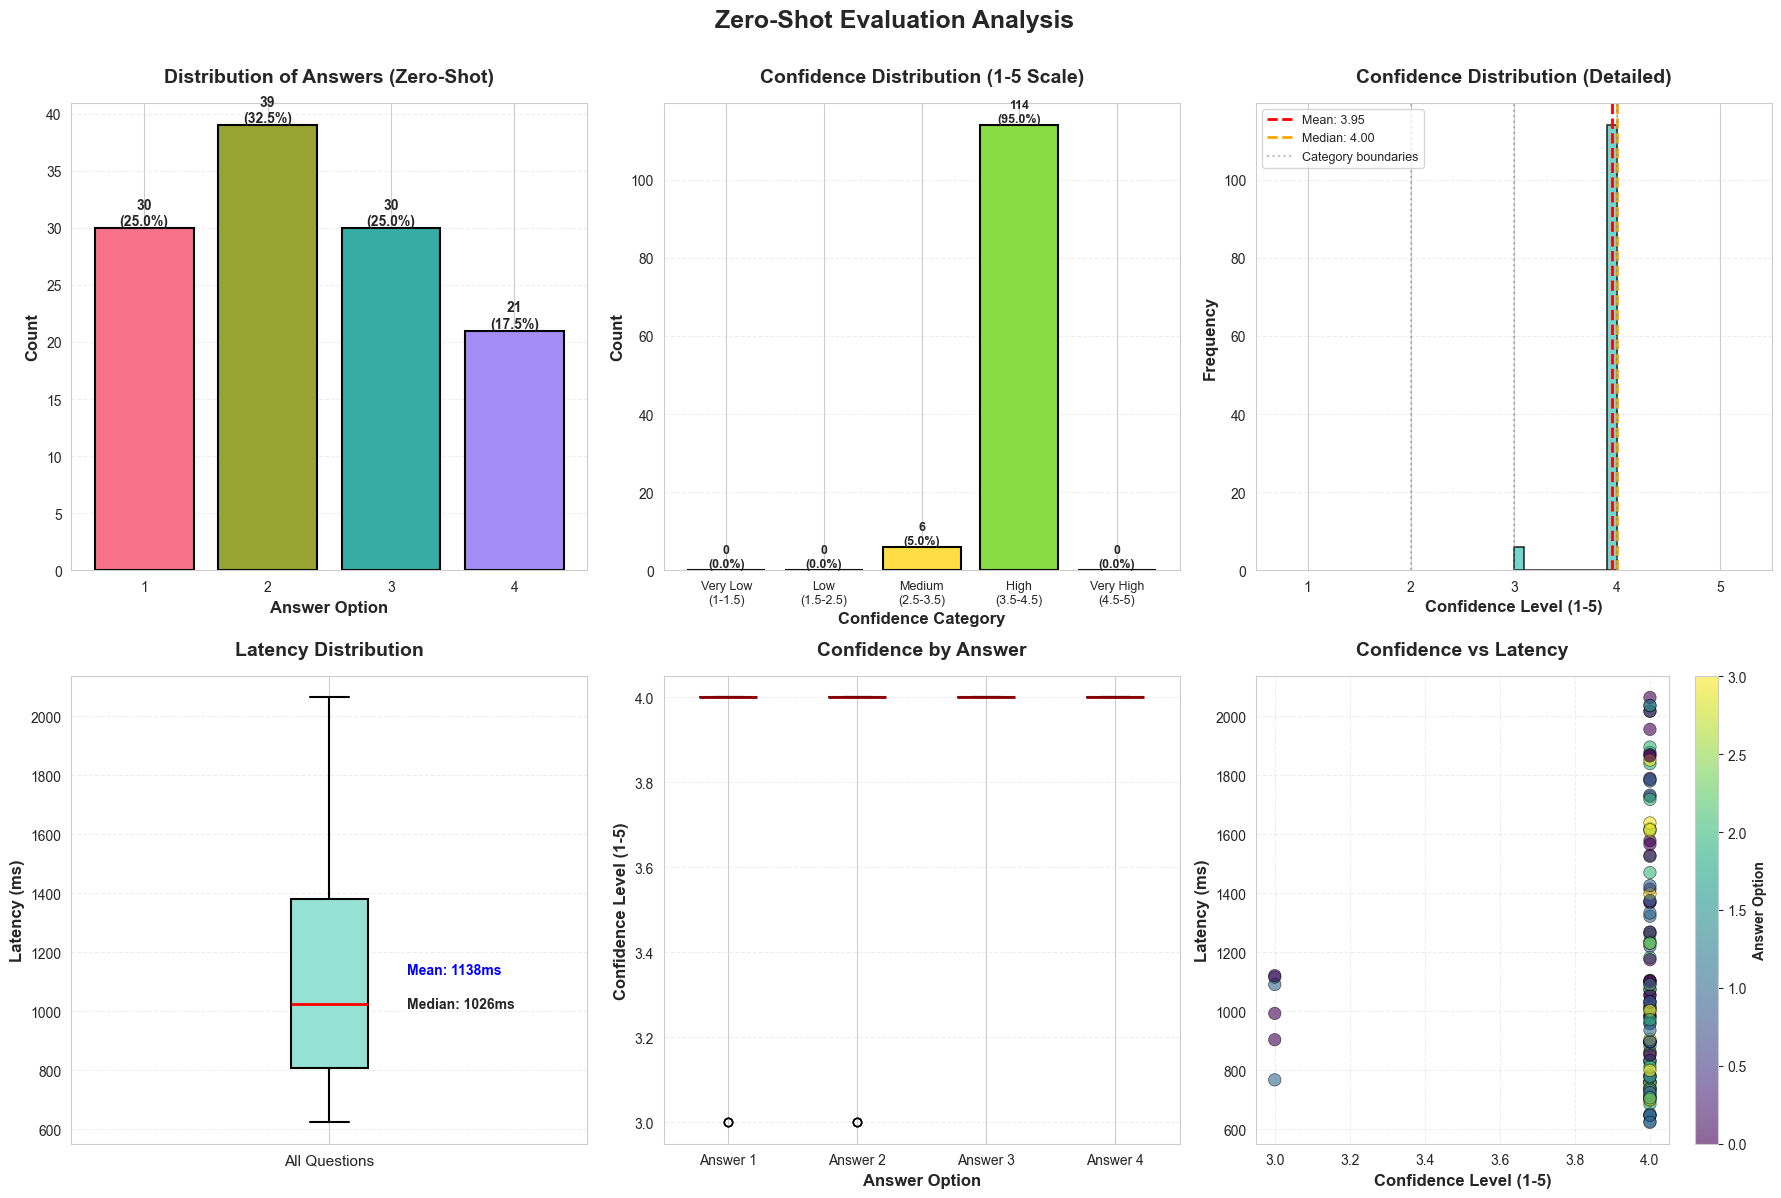


📊 Generating correlation heatmap...
   ✅ Heatmap saved: correlation_heatmap_zero_shot.png


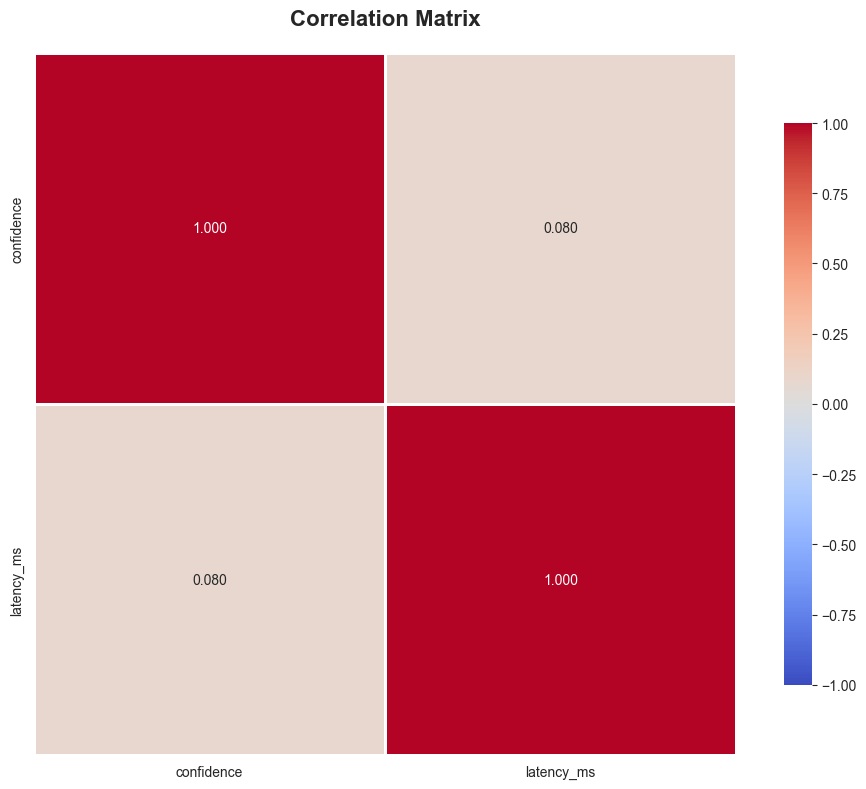


📊 Generating latency timeline...
   ✅ Timeline saved: latency_timeline_zero_shot.png


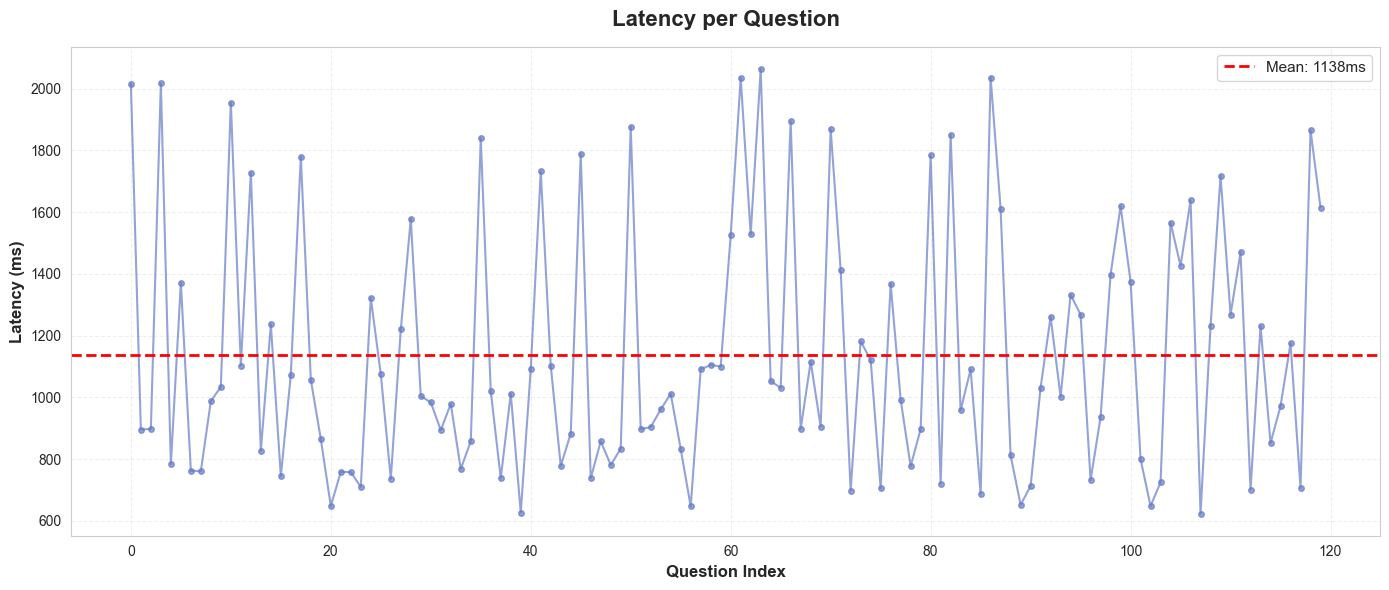


✅ All visualizations generated successfully!


In [12]:
# تنظیمات نمایش فارسی
plt.rcParams['font.family'] = 'Arial'
sns.set_style("whitegrid")
sns.set_palette("husl")

# ================== بخش نمودارها ==================
print("\n" + "="*70)
print("📊 Generating Visualizations")
print("="*70)

# ایجاد فیگور بزرگ با چند subplot
fig = plt.figure(figsize=(18, 12))

# ==================== نمودار 1: توزیع پاسخ نهایی ====================
ax1 = plt.subplot(2, 3, 1)
answer_counts = results['answer'].value_counts().sort_index()
colors = sns.color_palette("husl", len(answer_counts))
bars = ax1.bar(answer_counts.index.astype(str), answer_counts.values, color=colors, edgecolor='black', linewidth=1.5)

# افزودن درصد روی ستون‌ها
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}\n({height/len(results)*100:.1f}%)',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1.set_title('Distribution of Answers (Zero-Shot)', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Answer Option', fontsize=12, fontweight='bold')
ax1.set_ylabel('Count', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# ==================== نمودار 2: توزیع Confidence ====================
ax2 = plt.subplot(2, 3, 2)
# ✅ مقیاس 1-5 برای confidence
confidence_bins = [0, 1.5, 2.5, 3.5, 4.5, 5.1]
confidence_labels = ['Very Low\n(1-1.5)', 'Low\n(1.5-2.5)', 'Medium\n(2.5-3.5)', 'High\n(3.5-4.5)', 'Very High\n(4.5-5)']

results['conf_category'] = pd.cut(
    results['confidence'], 
    bins=confidence_bins, 
    labels=confidence_labels, 
    include_lowest=True,
    right=False
)
conf_counts = results['conf_category'].value_counts().sort_index()

# رنگ‌های gradient
colors_conf = ['#FF4444', '#FF8844', '#FFDD44', '#88DD44', '#44DD44']
bars2 = ax2.bar(range(len(conf_counts)), conf_counts.values, color=colors_conf, edgecolor='black', linewidth=1.5)

for i, bar in enumerate(bars2):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}\n({height/len(results)*100:.1f}%)',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2.set_xticks(range(len(conf_counts)))
ax2.set_xticklabels(conf_counts.index, fontsize=9)
ax2.set_title('Confidence Distribution (1-5 Scale)', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Confidence Category', fontsize=12, fontweight='bold')
ax2.set_ylabel('Count', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# ==================== نمودار 3: Histogram Confidence ====================
ax3 = plt.subplot(2, 3, 3)
ax3.hist(results['confidence'], bins=10, color='#4ECDC4', edgecolor='black', linewidth=1.2, alpha=0.8)
ax3.axvline(results['confidence'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {results["confidence"].mean():.2f}')
ax3.axvline(results['confidence'].median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {results["confidence"].median():.2f}')

# اضافه کردن vertical lines برای boundaries
ax3.axvline(2, color='gray', linestyle=':', linewidth=1.5, alpha=0.5, label='Category boundaries')
ax3.axvline(3, color='gray', linestyle=':', linewidth=1.5, alpha=0.5)
ax3.axvline(4, color='gray', linestyle=':', linewidth=1.5, alpha=0.5)

ax3.set_title('Confidence Distribution (Detailed)', fontsize=14, fontweight='bold', pad=15)
ax3.set_xlabel('Confidence Level (1-5)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax3.legend(fontsize=9, loc='upper left')
ax3.grid(axis='y', alpha=0.3, linestyle='--')
ax3.set_xlim([0.5, 5.5])

# ==================== نمودار 4: Boxplot Latency ====================
ax4 = plt.subplot(2, 3, 4)
valid_latency = results['latency_ms'].dropna()
if len(valid_latency) > 0:
    bp = ax4.boxplot(valid_latency, vert=True, patch_artist=True,
                      boxprops=dict(facecolor='#95E1D3', edgecolor='black', linewidth=1.5),
                      whiskerprops=dict(color='black', linewidth=1.5),
                      capprops=dict(color='black', linewidth=1.5),
                      medianprops=dict(color='red', linewidth=2))
    
    ax4.set_title('Latency Distribution', fontsize=14, fontweight='bold', pad=15)
    ax4.set_ylabel('Latency (ms)', fontsize=12, fontweight='bold')
    ax4.set_xticklabels(['All Questions'], fontsize=11)
    ax4.grid(axis='y', alpha=0.3, linestyle='--')
    
    # اضافه کردن آمار
    median_lat = valid_latency.median()
    mean_lat = valid_latency.mean()
    ax4.text(1.15, median_lat, f'Median: {median_lat:.0f}ms', fontsize=10, fontweight='bold', va='center')
    ax4.text(1.15, mean_lat, f'Mean: {mean_lat:.0f}ms', fontsize=10, fontweight='bold', va='center', color='blue')

# ==================== نمودار 5: Confidence به تفکیک Answer ====================
ax5 = plt.subplot(2, 3, 5)
answer_conf_data = []
answer_labels = []
for ans in sorted(results['answer'].dropna().unique()):
    conf_values = results[results['answer'] == ans]['confidence'].dropna()
    if len(conf_values) > 0:
        answer_conf_data.append(conf_values)
        answer_labels.append(f'Answer {ans}')

if len(answer_conf_data) > 0:
    bp2 = ax5.boxplot(answer_conf_data, labels=answer_labels, patch_artist=True,
                       boxprops=dict(facecolor='#FFB6B9', alpha=0.7, edgecolor='black', linewidth=1.5),
                       whiskerprops=dict(color='black', linewidth=1.5),
                       capprops=dict(color='black', linewidth=1.5),
                       medianprops=dict(color='darkred', linewidth=2))
    
    ax5.set_title('Confidence by Answer', fontsize=14, fontweight='bold', pad=15)
    ax5.set_xlabel('Answer Option', fontsize=12, fontweight='bold')
    ax5.set_ylabel('Confidence Level (1-5)', fontsize=12, fontweight='bold')
    ax5.grid(axis='y', alpha=0.3, linestyle='--')

# ==================== نمودار 6: Scatter Confidence vs Latency ====================
ax6 = plt.subplot(2, 3, 6)
valid_data = results.dropna(subset=['confidence', 'latency_ms', 'answer'])
if len(valid_data) > 0:
    scatter = ax6.scatter(valid_data['confidence'], valid_data['latency_ms'],
                          c=valid_data['answer'].astype('category').cat.codes,
                          cmap='viridis', s=80, alpha=0.6, edgecolors='black', linewidth=0.5)
    
    ax6.set_title('Confidence vs Latency', fontsize=14, fontweight='bold', pad=15)
    ax6.set_xlabel('Confidence Level (1-5)', fontsize=12, fontweight='bold')
    ax6.set_ylabel('Latency (ms)', fontsize=12, fontweight='bold')
    ax6.grid(alpha=0.3, linestyle='--')
    
    # Colorbar
    cbar = plt.colorbar(scatter, ax=ax6)
    cbar.set_label('Answer Option', fontsize=10, fontweight='bold')

# ==================== تنظیمات کلی ====================
plt.suptitle('Zero-Shot Evaluation Analysis',
             fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.99])

# ذخیره نمودار
viz_filename = 'visualizations_zero_shot.png'
plt.savefig(viz_filename, dpi=300, bbox_inches='tight', facecolor='white')
print(f"   ✅ Visualization saved: {viz_filename}")
plt.show()

# ==================== نمودارهای اضافی ====================

# نمودار 7: Heatmap همبستگی
print("\n📊 Generating correlation heatmap...")
fig2, ax7 = plt.subplots(figsize=(10, 8))

# ستون‌های عددی (بدون total_time_ms)
numeric_cols = ['confidence', 'latency_ms']
numeric_cols = [col for col in numeric_cols if col in results.columns]

if len(numeric_cols) > 1:
    corr_data = results[numeric_cols].corr()
    sns.heatmap(corr_data, annot=True, fmt='.3f', cmap='coolwarm', center=0,
                square=True, linewidths=2, cbar_kws={"shrink": 0.8},
                ax=ax7, vmin=-1, vmax=1)
    
    ax7.set_title('Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    heatmap_filename = 'correlation_heatmap_zero_shot.png'
    plt.savefig(heatmap_filename, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"   ✅ Heatmap saved: {heatmap_filename}")
    plt.show()
else:
    print("   ⚠️  Not enough numeric columns for correlation matrix")

# نمودار 8: Timeline latency
print("\n📊 Generating latency timeline...")
fig3, ax8 = plt.subplots(figsize=(14, 6))

valid_latency_timeline = results['latency_ms'].dropna()
if len(valid_latency_timeline) > 0:
    ax8.plot(valid_latency_timeline.index, valid_latency_timeline,
             marker='o', linestyle='-', linewidth=1.5, markersize=4,
             color='#667BC6', alpha=0.7)
    
    ax8.axhline(valid_latency_timeline.mean(),
                color='red', linestyle='--', linewidth=2,
                label=f'Mean: {valid_latency_timeline.mean():.0f}ms')
    
    ax8.set_title('Latency per Question', fontsize=16, fontweight='bold', pad=15)
    ax8.set_xlabel('Question Index', fontsize=12, fontweight='bold')
    ax8.set_ylabel('Latency (ms)', fontsize=12, fontweight='bold')
    ax8.legend(fontsize=11)
    ax8.grid(alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    timeline_filename = 'latency_timeline_zero_shot.png'
    plt.savefig(timeline_filename, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"   ✅ Timeline saved: {timeline_filename}")
    plt.show()

print("\n" + "="*70)
print("✅ All visualizations generated successfully!")
print("="*70)
